Load Dataset from DeepLoc


In [43]:
import pandas as pd

df = pd.read_csv("https://services.healthtech.dtu.dk/services/DeepLoc-2.0/data/Swissprot_Train_Validation_dataset.csv")

In [44]:
df.head()

,Unnamed: 0,ACC,Kingdom,Partition,Membrane,Cytoplasm,Nucleus,Extracellular,Cell membrane,Mitochondrion,Plastid,Endoplasmic reticulum,Lysosome/Vacuole,Golgi apparatus,Peroxisome,Sequence
0,0,Q28165,Metazoa,4,0.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,MAAAAAAAAAAGAAGGRGSGPGRRRHLVPGAGGEAGEGAPGGAGDY...
1,1,Q86U42,Metazoa,4,0.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,MAAAAAAAAAAGAAGGRGSGPGRRRHLVPGAGGEAGEGAPGGAGDY...
2,2,Q0GA42,Metazoa,3,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,MAAAAAAAAALGVRLRDCCSRGAVLLLFFSLSPRPPAAAAWLLGLR...
3,3,P82349,Metazoa,1,1.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,MAAAAAAAAATEQQGSNGPVKKSMREKAVERRNVNKEHNSNFKAGY...
4,4,Q7L5N1,Metazoa,1,0.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,MAAAAAAAAATNGTGGSSGMEVDAAVVPSVMACGVTGSVSVALHPL...


Extract Cytoplasm Presence Data

In [45]:
import numpy as np

y_data = df["Cytoplasm"].to_list()
y = 5
print(f"First {y} Entries: {y_data[:y]}")

First 5 Entries: [1.0, 1.0, 0.0, 1.0, 1.0]


Extract Protein Sequences

In [46]:
x_data = df["Sequence"].to_list()
x = 4
print(f"{x}th Entries: {x_data[x]}")

4th Entries: MAAAAAAAAATNGTGGSSGMEVDAAVVPSVMACGVTGSVSVALHPLVILNISDHWIRMRSQEGRPVQVIGALIGKQEGRNIEVMNSFELLSHTVEEKIIIDKEYYYTKEEQFKQVFKELEFLGWYTTGGPPDPSDIHVHKQVCEIIESPLFLKLNPMTKHTDLPVSVFESVIDIINGEATMLFAELTYTLATEEAERIGVDHVARMTATGSGENSTVAEHLIAQHSAIKMLHSRVKLILEYVKASEAGEVPFNHEILREAYALCHCLPVLSTDKFKTDFYDQCNDVGLMAYLGTITKTCNTMNQFVNKFNVLYDRQGIGRRMRGLFF


Extract Features: Amino acid normalized frequency count and sequence length

In [47]:
amino_acids = np.array(["A", "R", "N", "D", "C", "Q", "E", "G", "H", "I","L", "K", "M", "F", "P","S", "T", "W","Y","V"])

features = []
for seq in x_data: 
    if seq == " ":
        continue
    seq_length = len(seq)
    feature_vector = [seq_length]
    for amino in amino_acids:
        feature_vector.append(seq.count(amino)/seq_length)
    features.append(feature_vector)


print(f"First Entry: {features[:2]}")

First Entry: [[306, 0.11437908496732026, 0.0915032679738562, 0.03594771241830065, 0.032679738562091505, 0.006535947712418301, 0.013071895424836602, 0.13398692810457516, 0.13071895424836602, 0.013071895424836602, 0.032679738562091505, 0.049019607843137254, 0.032679738562091505, 0.0196078431372549, 0.026143790849673203, 0.09477124183006536, 0.06862745098039216, 0.029411764705882353, 0.0032679738562091504, 0.032679738562091505, 0.0392156862745098], [306, 0.11437908496732026, 0.0915032679738562, 0.032679738562091505, 0.032679738562091505, 0.006535947712418301, 0.013071895424836602, 0.13398692810457516, 0.13071895424836602, 0.013071895424836602, 0.032679738562091505, 0.049019607843137254, 0.032679738562091505, 0.0196078431372549, 0.026143790849673203, 0.09803921568627451, 0.06862745098039216, 0.029411764705882353, 0.0032679738562091504, 0.032679738562091505, 0.0392156862745098]]


In [48]:
nsamples =  len(x_data)
indices = np.arange(nsamples)
np.random.shuffle(indices)

train_split = int(nsamples*0.7)
test_split = int(nsamples*0.2) + train_split
train_idx, test_idx, validation_idx = indices[:train_split], indices[train_split:test_split], indices[test_split:]

print(f"train, test: {train_idx}")

train, test: [18681 21280 11388 ... 24078  7910 21957]


Data splitting for Testing (70%), Training (20%), and Validation (10%)

In [49]:

X = np.array(features)
y = np.array(y_data)

X_train, y_train = X[train_idx], y[train_idx]

X_test, y_test = X[test_idx], y[test_idx]
    
X_valid, y_valid = X[validation_idx], y[validation_idx]


print(X.shape)
print(X_train.shape)
print(X_test.shape)
print(X_valid.shape)
print(f"Y train_shape: {y_train.shape}")

(28303, 21)
(19812, 21)
(5660, 21)
(2831, 21)
Y train_shape: (19812,)


Standardization using Z-score

In [50]:
mean = np.mean(X_train, axis=0)
std = np.std(X_train, axis=0)
std[std == 0] = 1

X_train = (X_train - mean)/std
print(X_train)
X_test = (X_test - mean)/std

X_valid = (X_valid - mean)/std


[[-0.78482476 -1.31741475  1.65195328 ...  1.03857241  0.88602227
  -1.83497173]
 [-0.46269173  0.1082443  -0.15295484 ...  1.20789462 -0.04248051
   0.41859334]
 [-0.49490504 -0.60877644 -0.94635891 ... -0.59696515  0.07465899
  -0.44431607]
 ...
 [-0.65218175  0.68317665  0.93997439 ... -0.29399488  0.58018128
   1.66535511]
 [ 0.64203506 -0.41584056  0.0155506  ... -0.34354786  0.6173769
   0.24943642]
 [-0.1102403  -0.38201219 -0.10500804 ... -0.68211074 -0.37537717
  -0.97043251]]


In [51]:
import importlib
import protein_classifier

importlib.reload(protein_classifier)
from protein_classifier import ProteinClassifier

model = ProteinClassifier(x_train=X_train, y_train=y_train, x_test=X_test, y_test=y_test, x_valid=X_valid, y_valid=y_valid)

losses = model.train_cross_entropy()


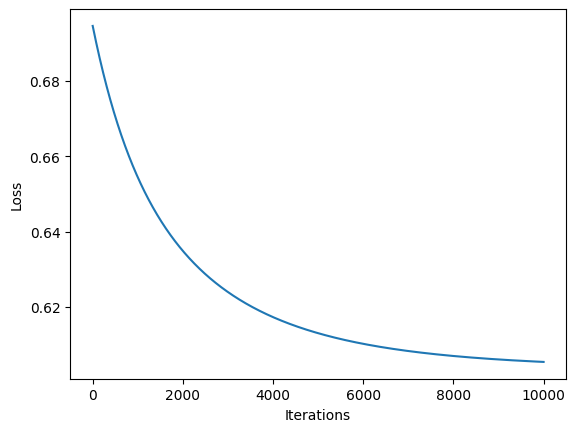

In [52]:
import matplotlib.pyplot as plt

plt.plot(losses)
plt.xlabel("Iterations")
plt.ylabel("Loss")
plt.show()



In [53]:
y_prob = model.predict_proba(X_test)
y_pred = (y_prob >= 0.5)

Model Evaluation

Evaluation Metrics

In [54]:
y_true = y_test 

TP = np.sum((y_pred == 1) & (y_true == 1))
TN = np.sum((y_pred == 0) & (y_true == 0))
FP = np.sum((y_pred == 1) & (y_true == 0))
FN = np.sum((y_pred == 0) & (y_true == 1))

accuracy = (TP + TN) / len(y_true)
recall = TP / (TP + FN) if (TP + FN) > 0 else 0.0
precision = TP / (TP + FP) if (TP + FP) > 0 else 0.0 

f1_score = 2 * (precision * recall)/(precision + recall)

print("TP:", TP, "TN:", TN, "FP:", FP, "FN:", FN)
print("Accuracy:", accuracy)
print("Recall:", recall)
print("Precision:", precision)
print("F1 score:", f1_score)


TP: 377 TN: 3295 FP: 393 FN: 1595
Accuracy: 0.6487632508833923
Recall: 0.19117647058823528
Precision: 0.4896103896103896
F1 score: 0.274981765134938


In [ ]:
y_prob = model.predict_proba(X_valid)
y_true = y_valid

print(y_prob.shape, y_true.shape)   # should both be (2831,)

best_f1 = 0
best_t = 0

f1_scores = []
thresholds = []

for t in np.linspace(0.1, 0.9, 50):
    y_pred = (y_prob >= t)

    TP = np.sum((y_pred == 1) & (y_true == 1))
    FP = np.sum((y_pred == 1) & (y_true == 0))
    FN = np.sum((y_pred == 0) & (y_true == 1))

    precision = TP / (TP + FP) if (TP + FP) > 0 else 0
    recall = TP / (TP + FN) if (TP + FN) > 0 else 0
    f1 = 2 * precision * recall / (precision + recall) if (precision + recall) > 0 else 0

    f1_scores.append(f1)
    thresholds.append(t)

    if f1 > best_f1:
        best_f1 = f1
        best_t = t

print("Best threshold:", best_t)
print("Best F1:", best_f1)

(2831,) (2831,)
Best threshold: 0.29591836734693877
Best F1: 0.5738311469895728


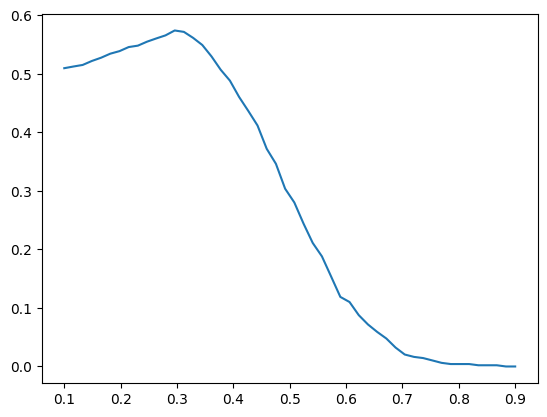

In [56]:
plt.plot(thresholds, f1_scores)

In [57]:
print(np.min(y_prob), np.max(y_prob), np.mean(y_prob))
print(y_prob[:10])

0.041075386774053105 0.9942707476357212 0.3655228769781841
[0.13951436 0.18032061 0.29791469 0.53154207 0.69427034 0.4490582
 0.20223396 0.42751274 0.49898839 0.32045807]
